# 01B: Exploratory Data Analysis

Characterises the fleet: site/circuit counts, geographic spread, export limits, key-table schemas, and single-day diagnostic plots.

In [2]:
import sys, pathlib
sys.path.insert(0, str(pathlib.Path('..').resolve()))
# sys.path.insert(0, str(pathlib.Path('lib').resolve()))

from shared.aws_config import aq, dread, s3_ls
from shared.ciccada_config import SA, SAI, AS4777, TABLES
from data_query.lib import explore_plots as ep
from data_query.lib import site_selection as ss
from data_query.lib import fleet_eda_diagnostics as fd

import pandas as pd
import numpy as np

## Sites and circuits

In [3]:
# -----------------------------------------------------------------------------
# Assumptions:
# sites  = physical locations (one row per address)
# circuits = monitoring points within a site (one row per phase/device)
# is_pv = True means it's a solar PV circuit (not load, battery, etc.)
# -----------------------------------------------------------------------------

site_count = aq("SELECT count(*) AS n_sites FROM sites", database=SAI)
print("Total sites:", site_count["n_sites"].iloc[0])

Total sites: 41393


In [4]:
circuit_counts = aq("""
    SELECT
        is_pv,
        count(*)          AS n_circuits,
        count(DISTINCT site_id) AS n_sites
    FROM circuits
    GROUP BY is_pv
    ORDER BY is_pv DESC
""", 
database=SAI)
circuit_counts

# is_pv=True rows are what the telemetry analysis is built on.
# The values below double count sites because many sites have both PV and non-PV circuits.

,is_pv,n_circuits,n_sites
0,True,79686,39733
1,False,91725,38191


In [5]:
# How many circuits per site?
circuits_per_site = aq("""
    SELECT
        circuit_count,
        count(*) AS n_sites
    FROM (
        SELECT site_id, count(*) AS circuit_count
        FROM circuits
        WHERE is_pv = True
        GROUP BY site_id
    )
    GROUP BY circuit_count
    ORDER BY circuit_count
""", database=SAI)
circuits_per_site

,circuit_count,n_sites
0,1,22454
1,2,3527
2,3,11556
3,4,432
4,5,51
5,6,1195
6,7,22
7,8,11
8,9,224
9,10,7


## Geographic spread

In [6]:
# -----------------------------------------------------------------------------
# Geographic spread — use meta_up23c, not sites
# -----------------------------------------------------------------------------

states = aq("""
    SELECT state, count(*) AS n_sites
    FROM meta_up23c
    GROUP BY state
    ORDER BY n_sites DESC
""", database=SAI)
states

,state,n_sites
0,NSW,26676
1,QLD,18276
2,VIC,5741
3,SA,4917
4,WA,2452
5,TAS,1086
6,ACT,944
7,NT,478


In [7]:
# -----------------------------------------------------------------------------
# Use partition_lookup (tiny table) rather than querying ts directly.
# Reading min/max timestamps from a billions-row table is expensive;
# the lookup table gives you the answer for free.
# -----------------------------------------------------------------------------

partitions = aq("SELECT * FROM partition_lookup ORDER BY year, month", database=SA)
partitions
# Each row = one (year, month) partition that exists in the ts table.
# The first and last rows tell you the data window.

,year,month,is_pv
0,2024,1,False
1,2024,1,True
2,2024,2,False
3,2024,2,True
4,2024,3,False
5,2024,3,True
6,2024,4,True
7,2024,4,False
8,2024,5,True
9,2024,5,False


In [8]:
unique_months = partitions[['year', 'month']].drop_duplicates().sort_values(['year', 'month'])

print("Data covers:")
print(f"  From: {unique_months['year'].iloc[0]}-{str(unique_months['month'].iloc[0]).zfill(2)}")
print(f"  To:   {unique_months['year'].iloc[-1]}-{str(unique_months['month'].iloc[-1]).zfill(2)}")
print(f"  Total months: {len(unique_months)}")

Data covers:
  From: 2024-01
  To:   2025-06
  Total months: 18


## Export limits (flex_export_detected)

In [9]:
aq('''
SELECT flex_export_detected, count(DISTINCT site_id) AS n_sites
FROM meta_up23c
WHERE is_pv = True
GROUP BY flex_export_detected
''', database='solar_analytics_iceberg')

,flex_export_detected,n_sites
0,True,539
1,False,15609


In [10]:
# ═══════════════════════════════════════════════════════════════════════════════
# flex_export_detected diagnostic checks
# ═══════════════════════════════════════════════════════════════════════════════

#  Check 1: Where are the flagged sites?
flex_by_dnsp = aq("""
    SELECT
        flex_export_detected,
        state,
        dnsp_name,
        count(DISTINCT site_id)  AS n_sites,
        round(avg(ac_capacity_kw), 1) AS avg_ac_kw,
        round(avg(export_limit_kw), 1) AS avg_export_limit_kw
    FROM meta_up23c
    WHERE is_pv = True
    GROUP BY flex_export_detected, state, dnsp_name
    ORDER BY flex_export_detected DESC, n_sites DESC
""", database='solar_analytics_iceberg')

print("Flex-export sites by state and DNSP:")
print(flex_by_dnsp.to_string(index=False))

# Check 2: Do flagged sites have explicit export limits?
# If export_limit_kw is set AND is less than ac_capacity_kw, 
# that's a signal the site really is constrained.

flex_export_limits = aq("""
    SELECT
        flex_export_detected,
        count(DISTINCT site_id) AS n_sites,
        sum(CASE WHEN export_limit_kw IS NOT NULL THEN 1 ELSE 0 END) AS has_export_limit,
        sum(CASE WHEN export_limit_kw IS NOT NULL
                  AND export_limit_kw < ac_capacity_kw THEN 1 ELSE 0 END)
            AS export_limit_below_nameplate
    FROM (
        SELECT DISTINCT site_id, ac_capacity_kw, export_limit_kw, flex_export_detected
        FROM meta_up23c
        WHERE is_pv = True
    )
    GROUP BY flex_export_detected
""", database='solar_analytics_iceberg')

print("\nExport limit breakdown:")
print(flex_export_limits.to_string(index=False))

Flex-export sites by state and DNSP:
 flex_export_detected state                   dnsp_name  n_sites  avg_ac_kw  avg_export_limit_kw
                 True   QLD                     Energex      150        9.8                  5.3
                 True   QLD                       Ergon      137       10.0                  5.0
                 True   NSW                   Essential       69       14.0                  4.4
                 True   NSW                   Endeavour       30        7.7                  5.6
                 True    SA                        SAPN       28        9.8                  5.0
                 True   NSW                     Ausgrid       22        8.3                  5.0
                 True   VIC                      Ausnet       20        7.9                  3.6
                 True    WA                        <NA>       18        7.8                  1.5
                 True   QLD                     Ausgrid       17        9.7               

## Schema of the key tables

In [11]:
# Schema discovery for all Iceberg tables.

iceberg_tables = [
    # stage 0
    "ts",
    "meta_up23c",
    # Stage 1 rebuilds
    "structured_data_v2_flex_included",
    "all_uncurtailedpv_v2_flex_included",
    # Stage 2 rebuilds
    "conformance_voltvar_v2_flex_included",
    "conformance_voltwatt_v2_flex_included",
    "conformance_voltwattghi_v2_flex_included",
    # not rebuilt. still legacy
    "conformance_antiisland",
    "conformance_sust_op_3w",
]

schemas = {}
for t in iceberg_tables:
    try:
        row = aq(f"SELECT * FROM {t} LIMIT 1", database=SAI)
        schemas[t] = pd.DataFrame({
            "column": row.columns.tolist(),
            "dtype":  [str(d) for d in row.dtypes.tolist()],
        })
        print(f"OK  {t:32s} {len(row.columns)} columns")
    except Exception as e:
        print(f"ERR {t:32s} {e}")

OK  ts                               16 columns
OK  meta_up23c                       38 columns
OK  structured_data_v2_flex_included 23 columns
OK  all_uncurtailedpv_v2_flex_included 17 columns
OK  conformance_voltvar_v2_flex_included 34 columns
OK  conformance_voltwatt_v2_flex_included 13 columns
OK  conformance_voltwattghi_v2_flex_included 17 columns
OK  conformance_antiisland           9 columns
OK  conformance_sust_op_3w           9 columns


In [12]:
# Open up schemas here:
schemas['structured_data_v2_flex_included']

,column,dtype
0,site_id,Int64
1,t_stamp,datetime64[us]
2,actual_day,object
3,actual_tod,string
4,v,float64
5,q_kvar_norm,float64
6,p_kw_norm,float64
7,s_norm,float64
8,ghi,float64
9,cloud_type,Int32


In [13]:
# Open up schemas here:
schemas['all_uncurtailedpv_v2_flex_included']

,column,dtype
0,site_id,Int64
1,t_stamp,datetime64[us]
2,year,Int32
3,month,Int32
4,uncurtailed_p,float64
5,p_kw,float64
6,ghi,float64
7,n_train,Int64
8,model_prediction_raw,float64
9,uncurtailed_p_floored,float64


In [14]:
# Open up schemas here:
schemas['ts']

,column,dtype
0,circuit_id,Int64
1,t_stamp,datetime64[us]
2,power,float64
3,energy,float64
4,energy_reactive,float64
5,energy_import,float64
6,energy_export,float64
7,energy_reactive_import,float64
8,energy_reactive_export,float64
9,power_factor,float64


In [15]:
# Open up schemas here:
schemas['meta_up23c']

,column,dtype
0,site_id,Int64
1,state,string
2,postcode,Int32
3,longitude,float64
4,latitude,float64
5,dnsp_name,string
6,dc_capacity_kw,float64
7,ac_capacity_kw,float64
8,export_limit_kw,float64
9,monitoring_start,datetime64[us]


In [16]:
# Quick look at some data:
pd.set_option('display.max_columns', None)
aq("SELECT * FROM structured_data_v2_flex_included WHERE year = 2024 AND month = 1 LIMIT 5", database=SAI)

,site_id,t_stamp,actual_day,actual_tod,v,q_kvar_norm,p_kw_norm,s_norm,ghi,cloud_type,cs_day,cs_tod,p_kw_norm_cs,ghi_cs,cloud_type_cs,s_99,ac_capacity_kw,normalization_capacity,normalization_basis,voltage_aggregation,flex_selection,year,month
0,739770887,2024-01-19 06:00:00,2024-01-19,16:00:00.000,240.900000,-0.003235,0.672240,0.672247,583.32,0,2024-01-21,16:00:00.000,0.576180,607.15,0,15.547103,25.0,15.547103,s_99,avg,include,2024,1
1,1487434951,2024-01-22 19:40:00,2024-01-23,05:40:00.000,238.683333,-0.000083,0.002511,0.002513,46.42,0,2024-01-22,05:40:00.000,0.003769,50.21,0,78.655650,110.0,78.655650,s_99,avg,include,2024,1
2,838576903,2024-01-28 22:50:00,2024-01-29,08:50:00.000,233.150000,0.005258,0.485131,0.485159,648.69,0,2024-01-29,08:50:00.000,0.509767,648.69,0,8.004636,8.2,8.004636,s_99,avg,include,2024,1
3,739770887,2024-01-20 05:15:00,2024-01-20,15:15:00.000,237.250000,0.008867,0.465031,0.465116,379.55,8,2024-01-21,15:15:00.000,0.702203,735.23,0,15.547103,25.0,15.547103,s_99,avg,include,2024,1
4,1487434951,2024-01-22 06:30:00,2024-01-22,16:30:00.000,238.750000,0.007945,0.604525,0.604577,549.06,0,2024-01-22,16:30:00.000,0.618314,584.86,0,78.655650,110.0,78.655650,s_99,avg,include,2024,1


## Circuit bands

In [17]:
# Circuit count banded: makes the 1-to-60 range more interpretable
circuit_profile = aq("""
    SELECT
        CASE
            WHEN circuit_count = 1  THEN '1  - single phase'
            WHEN circuit_count = 2  THEN '2  - split or data gap'
            WHEN circuit_count = 3  THEN '3  - three phase'
            WHEN circuit_count <= 6 THEN '4-6 - multi-array or battery'
            ELSE                         '7+  - commercial / large site'
        END AS circuit_profile,
        count(*) AS n_sites,
        round(100.0 * count(*) / sum(count(*)) OVER (), 1) AS pct
    FROM (
        SELECT site_id, count(*) AS circuit_count
        FROM circuits
        WHERE is_pv = True
        GROUP BY site_id
    )
    GROUP BY 1
    ORDER BY min(circuit_count)
""", database=SAI)
circuit_profile

,circuit_profile,n_sites,pct
0,1 - single phase,22454,56.5
1,2 - split or data gap,3527,8.9
2,3 - three phase,11556,29.1
3,4-6 - multi-array or battery,1678,4.2
4,7+ - commercial / large site,518,1.3


## Fleet characteristics

In [18]:
# -----------------------------------------------------------------------------
# Site summary four separate queries, one per count
# -----------------------------------------------------------------------------

n_sites         = aq("SELECT count(DISTINCT site_id) AS n FROM sites",       database=SAI)["n"].iloc[0]
n_meta_up23c    = aq("SELECT count(DISTINCT site_id) AS n FROM meta_up23c",  database=SAI)["n"].iloc[0]
n_pv_circuits   = aq("SELECT count(DISTINCT site_id) AS n FROM circuits WHERE is_pv = True", database=SAI)["n"].iloc[0]
#n_single_inv    = aq("SELECT count(*) AS n FROM meta_single_inverters",       database=SA) ["n"].iloc[0]

site_summary = pd.DataFrame([{
    "total_in_sites_table":       n_sites,
    "sites_in_meta_up23c":        n_meta_up23c,
    "sites_with_pv_circuit":      n_pv_circuits
#    "meta_single_inverters_rows": n_single_inv,
}])
site_summary

,total_in_sites_table,sites_in_meta_up23c,sites_with_pv_circuit
0,41393,16148,39733


## Single-day diagnostic plots

Pick a site + date, pull one day, convert to AEST, and plot. Two views:
- `plot_operational`: Volt-Watt + Volt-VAr response
- `plot_protective`: sustained-operation + anti-islanding (over/under-voltage)

In [19]:
# =============================================================================
# Select a response mode and pull a ranked site list
# =============================================================================
# RESPONSE_MODE : "voltwatt" | "voltvar" | "sust_op" | "sust_op_3w" | "antiisland"
# BEHAVIOUR     : "nonconforming" | "conforming"
# PLOT_TYPE     : "operational" | "protective"
# YEAR / MONTH  : MONTH=None ranks over the full year
#
# All conformance tables live in solar_analytics_iceberg (SAI).
# Ranking metric per mode:
#   voltwatt   — nonconformance_voltwatt_count
#   voltvar    — nonconformance_voltvar_red_count  (severe Q deviation only)
#                extra breakdown columns also pulled for context
#   sust_op    — nonconformance_sust_op_count
#   sust_op_3w — nonconformance_sust_op_3w_count
#   antiisland — nonconformance_antiisland_count
#
# NOTE on voltvar category name swap (pipeline bug from inherited code, old database):
#   q_minor_deviation  = 10–90% band  (larger shortfall — counterintuitively named)
#   q_major_deficit    = 90–110% band (near-miss   — counterintuitively named)
# =============================================================================

# =============================================================================
#### Q_impact = signed abs(Q_kvar) / abs(nearest permitted final band edge) ####
#         Q_impact < -10%   = Adverse
# -10% <= Q_impact <= +10%  = Inactive
# +10% <  Q_impact <= +90%  = Major deficit
# +90% <= Q_impact <= +110% = Minor deviation
# +110% < Q_impact          = Major surplus

mode = "voltwatt"

# Rank sites for a mechanism
ranked = ss.rank_sites(
    mode=mode, 
    aq_func=aq, 
    behaviour="conforming",
    year=2024, 
    min_days=20,
    n_results=100)
ranked

CONFORMING sites: voltwatt  |  period: 2024  |  table: conformance_voltwatt_v2_flex_included
Returned 100 sites. Top = most conforming.


,site_id,nonconf_intervals,total_intervals,n_days,nonconf_pct
0,258427234,0,3777,726,0.0
1,220364585,0,8,718,0.0
2,1194799385,0,77,732,0.0
3,1393908514,0,334,400,0.0
4,204607242,0,1,732,0.0
...,...,...,...,...,...
95,140451063,0,26,729,0.0
96,748418615,0,206,732,0.0
97,328612358,0,382,541,0.0
98,1651930370,0,132,732,0.0


In [20]:
ranked[:30]

,site_id,nonconf_intervals,total_intervals,n_days,nonconf_pct
0,258427234,0,3777,726,0.0
1,220364585,0,8,718,0.0
2,1194799385,0,77,732,0.0
3,1393908514,0,334,400,0.0
4,204607242,0,1,732,0.0
5,1020898295,0,69,731,0.0
6,684111657,0,1641,732,0.0
7,54169609,0,15,724,0.0
8,1453538481,0,11,732,0.0
9,468471329,0,3,732,0.0


In [21]:
# 2. Pull that site nameplate/year/month/polarity
SITE_ID = ranked["site_id"].iloc[3]
# SITE_ID = 1033373679
# SITE_ID = 2134086510
# SITE_ID = 465008538
# SITE_ID = 276149647
SITE_ID = 1644145371
df, info = ss.pull_site_telemetry(SITE_ID, mode, aq, year=2025, month=None)

Site 1644145371  |  QLD / Ergon  |  8.0 kW  |  Generic Inverter 8kW
Data: 2024-01-01 -> 2025-12-31  |  polarity -1
Auto-selected month 3 (of available [1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12])
Rows: 8,696  (2025-03-01 -> 2025-04-01)


In [22]:
# 3. Which day to plot?
ss.suggest_days(df, mode)

Days with V > 253.0 V (most first):
t_stamp_aest
2025-03-14    18
2025-03-20    12
2025-03-07     7
2025-03-11     6
2025-03-05     5
2025-03-15     3
2025-03-03     3
2025-03-04     3
2025-03-31     3
2025-03-24     3
2025-03-13     2
2025-03-22     2
2025-03-30     2
2025-03-01     1
2025-03-02     1

  -> best candidate: 2025-03-14  (18 intervals)


t_stamp_aest
2025-03-14    18
2025-03-20    12
2025-03-07     7
2025-03-11     6
2025-03-05     5
2025-03-15     3
2025-03-03     3
2025-03-04     3
2025-03-31     3
2025-03-24     3
2025-03-13     2
2025-03-22     2
2025-03-30     2
2025-03-01     1
2025-03-02     1
2025-03-29     1
Name: voltage, dtype: int64

### Operational plots

Month pulled: 2025 3
Dates available: [datetime.date(2025, 3, 1), datetime.date(2025, 3, 2), datetime.date(2025, 3, 3), datetime.date(2025, 3, 4), datetime.date(2025, 3, 5)] ...


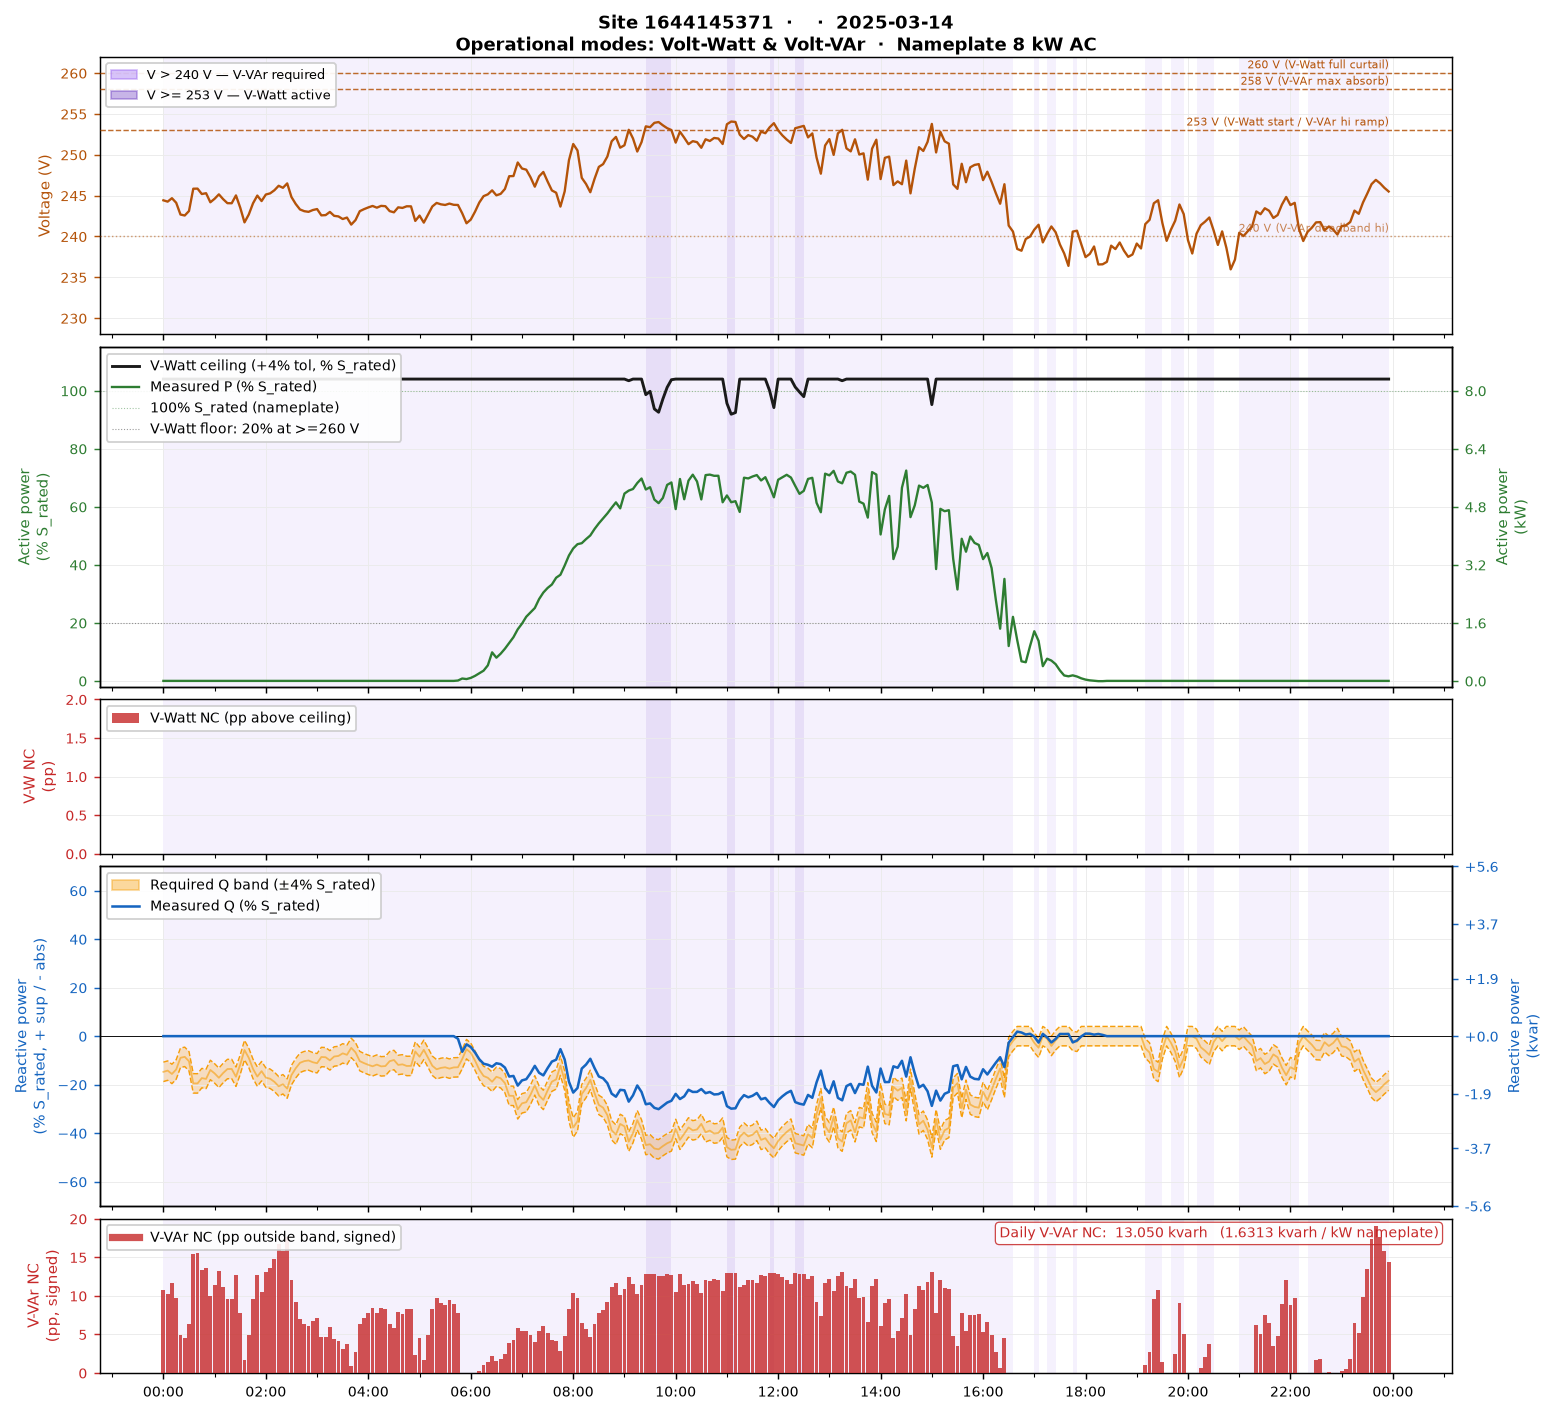


Volt-Watt:  0 non-conforming intervals
Volt-VAr:   230 non-conforming intervals  |  13.050 kvarh  (1.6313 kvarh/kW)


In [24]:
# 4. Plot pick a date that's actually in df
# df onlys pulls one month, so pick a date from the printed list above or from suggest_days().
print("Month pulled:", info["plot_year"], info["plot_month"])
print("Dates available:", sorted(df["t_stamp_aest"].dt.date.unique())[:5], "...")

ZOOM_DATE = "2025-03-14"
df_day = df[df["t_stamp_aest"].dt.date == pd.Timestamp(ZOOM_DATE).date()].copy()
assert len(df_day) > 0, f"No rows for {ZOOM_DATE}. Pick from the dates printed above or from suggest_days()."

ep.plot_operational(df_day, info["site_id"], info["ac_capacity_kw"], ZOOM_DATE, AS4777)

#### Isolated Volt-Watt

In [25]:
site_year = aq(f"""
    SELECT
        site_id,
        sum(nonconformance_voltwattghi_count) AS nonconf_count,
        sum(assessable_count)                 AS response_supported_count
    FROM {TABLES['conformance_voltwattghi']}
    WHERE year IN (2024, 2025)
    GROUP BY site_id
""", database=SAI)

MIN_INTERVALS = 50   # require decent evidence, not one lucky interval
site_year["nonconf_frac"] = site_year["nonconf_count"] / site_year["response_supported_count"]
conformant_sites = site_year[
    (site_year["response_supported_count"] >= MIN_INTERVALS) &
    (site_year["nonconf_frac"] < 0.10)
].sort_values("response_supported_count", ascending=False)

print(f"{len(conformant_sites)} conformant sites with >= {MIN_INTERVALS} response-supported intervals")
conformant_sites.head(20)

109 conformant sites with >= 50 response-supported intervals


,site_id,nonconf_count,response_supported_count,nonconf_frac
15941,1783345185,41,2413,0.016991
4901,284910195,35,1435,0.02439
133,1616936858,70,952,0.073529
490,959144991,7,906,0.007726
9333,2063146742,0,890,0.0
3678,1588083868,24,797,0.030113
9087,45544685,64,723,0.08852
6768,421761528,11,660,0.016667
9487,20579931,31,614,0.050489
3644,293338588,4,536,0.007463


In [26]:
site_ids_sql = ", ".join(str(int(s)) for s in conformant_sites["site_id"].head(50))

candidate_days = aq(f"""
    SELECT
        c.site_id, c.year, c.month, c.day,
        m.state, m.dnsp_name, m.ac_capacity_kw, m.manufacturer,
        c.P_kW_sum, c.total_count, c.assessable_count,
        c.nonconformance_voltwattghi_count
    FROM {TABLES['conformance_voltwattghi']} c
    JOIN (
        SELECT DISTINCT site_id, state, dnsp_name, ac_capacity_kw, manufacturer
        FROM meta_up23c WHERE is_pv = True
    ) m ON m.site_id = c.site_id
    WHERE c.day_night = 'day'
      AND c.site_id IN ({site_ids_sql})
      AND c.assessable_count >= 5
    ORDER BY c.nonconformance_voltwattghi_count ASC, c.assessable_count DESC
    LIMIT 30
""", database=SAI)

candidate_days

,site_id,year,month,day,state,dnsp_name,ac_capacity_kw,manufacturer,P_kW_sum,total_count,assessable_count,nonconformance_voltwattghi_count
0,1835709174,2024,1,18,SA,SAPN,5.00,SolaX,312.184763,100,74,0
1,991251222,2025,1,18,VIC,Powercor,5.00,GoodWe,354.657457,85,60,0
2,1783345185,2025,9,26,QLD,Ergon,8.00,Generic Inverter,441.014240,91,59,0
3,1835709174,2024,1,21,SA,SAPN,5.00,SolaX,335.454726,81,56,0
4,20579931,2024,2,7,SA,SAPN,5.00,SolaX,359.955664,92,54,0
5,991251222,2025,1,17,VIC,Powercor,5.00,GoodWe,333.632744,77,50,0
6,830837288,2024,1,19,NSW,Ausgrid,8.00,Sungrow,566.046527,90,49,0
7,1783345185,2024,10,24,QLD,Ergon,8.00,Generic Inverter,515.671600,103,47,0
8,1835709174,2024,1,19,SA,SAPN,5.00,SolaX,321.636784,83,46,0
9,1783345185,2025,4,24,QLD,Ergon,8.00,Generic Inverter,458.228640,93,45,0


1835709174 2024-01-18 | assessable: 74 | NC that day: 0
Site 1835709174  |  SA / SAPN  |  5.0 kW  |  SolaX X1-5.0T
Data: 2024-01-01 -> 2024-07-30  |  polarity 1
Rows: 8,928  (2024-01-01 -> 2024-02-01)


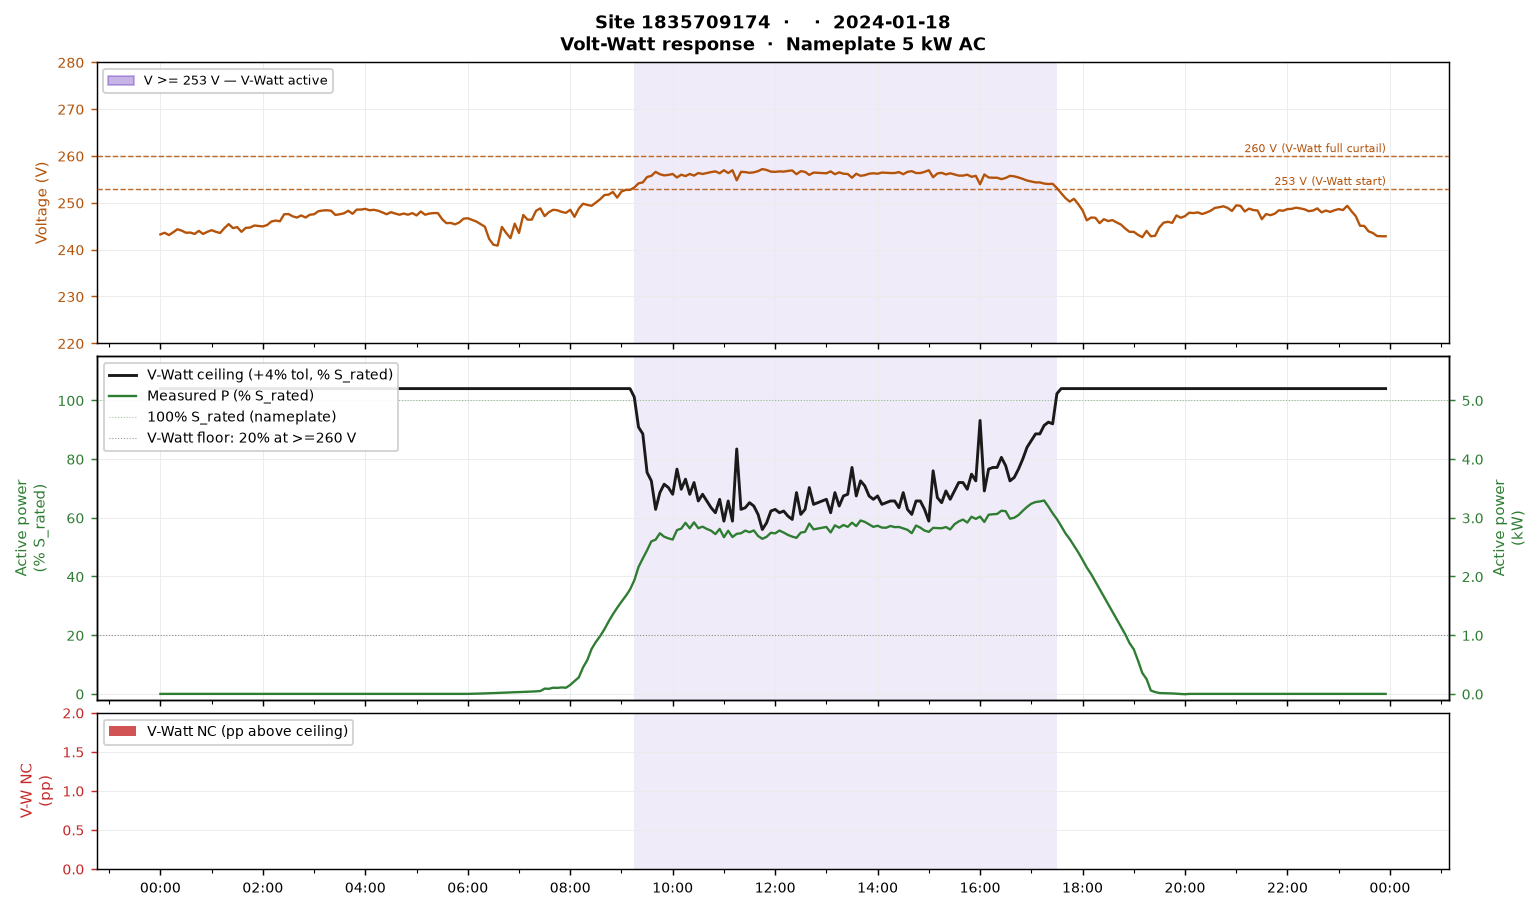


Volt-Watt:  0 non-conforming intervals


In [27]:
row = candidate_days.iloc[0]
SITE_ID   = int(row["site_id"])
ZOOM_DATE = f'{int(row["year"])}-{int(row["month"]):02d}-{int(row["day"]):02d}'
print(SITE_ID, ZOOM_DATE, "| assessable:", row["assessable_count"], "| NC that day:", row["nonconformance_voltwattghi_count"])

df, info = ss.pull_site_telemetry(SITE_ID, "voltwatt", aq, year=int(row["year"]), month=int(row["month"]))
df_day = df[df["t_stamp_aest"].dt.date == pd.Timestamp(ZOOM_DATE).date()].copy()

ep.plot_voltwatt_only(df_day, info["site_id"], info["ac_capacity_kw"], ZOOM_DATE, AS4777)

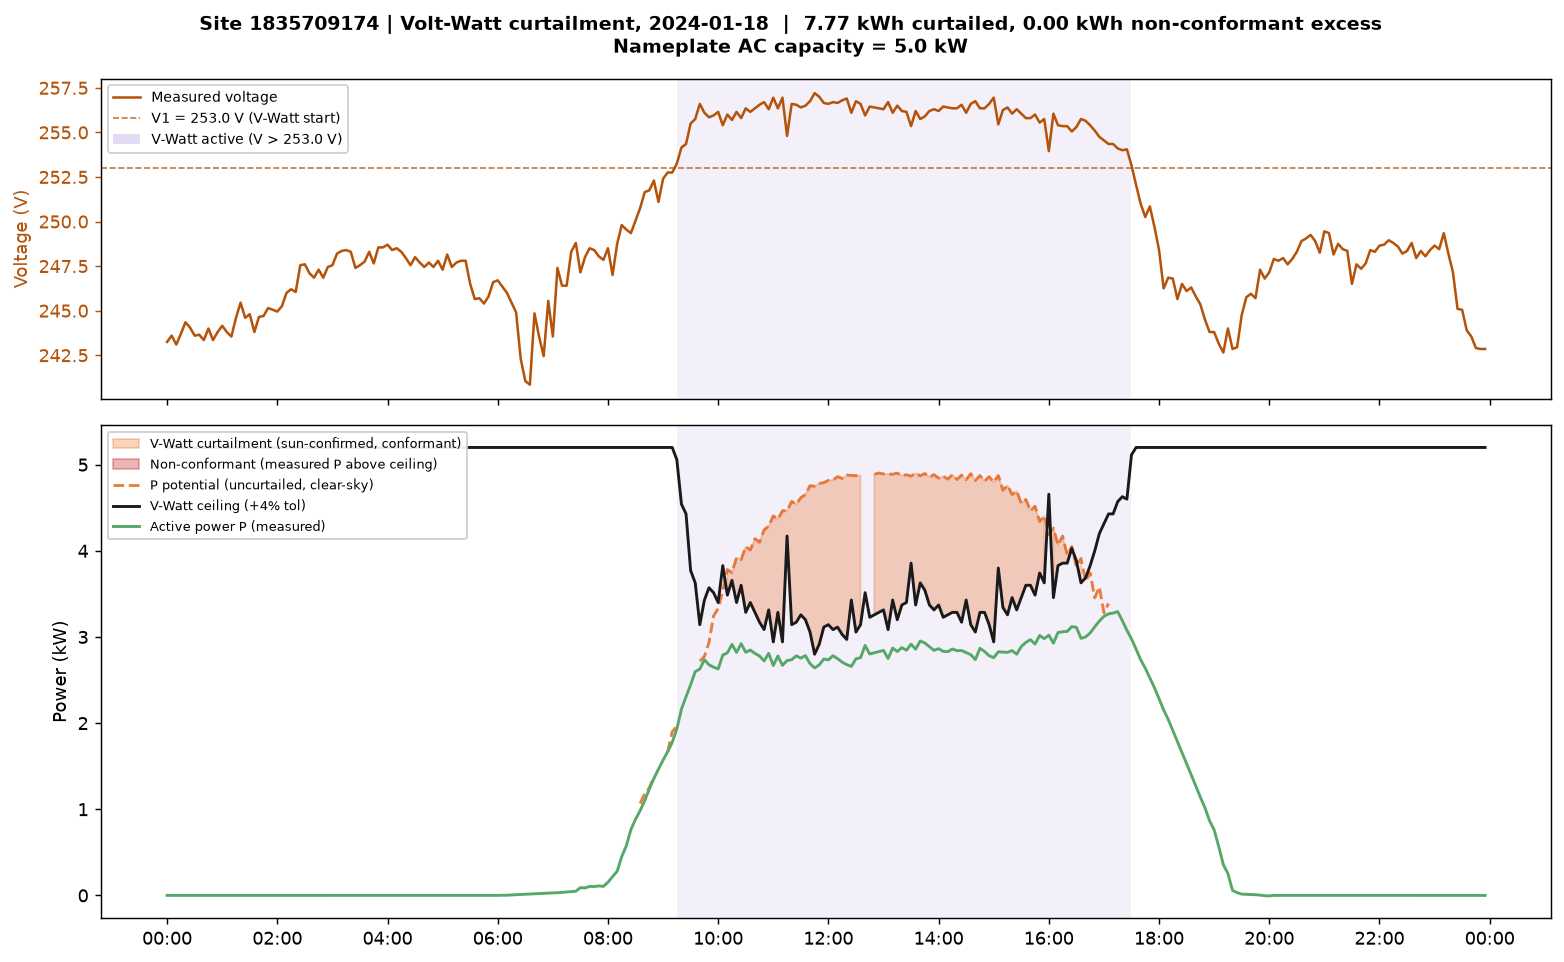

Curtailed (sun-confirmed, conformant): 7.77 kWh across 74 intervals
Non-conformant excess (measured > ceiling): 0.00 kWh across 0 intervals


In [ ]:
from data_query.lib import voltwatt_curtailment as vwc

TARGET_SITE = SITE_ID 
TARGET_DATE = ZOOM_DATE

day_df = vwc.fetch_voltwatt_day_data(
    aq, site_id=TARGET_SITE, date_str=TARGET_DATE,
    database=SAI,
    all_uncurtailedpv_table=TABLES["all_uncurtailedpv"],
)

vwc.plot_voltwatt_curtailment_day(
    day_df,
    site_id=TARGET_SITE,
    date_str=TARGET_DATE,
    as4777=AS4777,
    redact_site=True,
);

#### Monthly Volt-VAr

In [ ]:
# uses the month that pull_site_telemetry resolved
scatter_df = ss.pull_month_scatter(
    info["site_id"], 
    info["plot_year"],
    info["plot_month"], 
    aq
)
ep.plot_vvar_month_scatter(
    scatter_df, 
    info["site_id"], 
    info["ac_capacity_kw"],
    f"{info['plot_year']}-{info['plot_month']:02d}",
    manufacturer=info["manufacturer"]
)

### Operational diagnostics

In [ ]:
stored_verdict = fd.fetch_stored_day_verdict(
    SITE_ID,
    ZOOM_DATE,
    aq,
    SAI,
)

recomputed = fd.recompute_vvar_day(
    SITE_ID,
    ZOOM_DATE,
    aq,
    SAI,
)

interval_summary, bucket_summary = (
    fd.summarise_recomputed_day(recomputed)
)

display(stored_verdict)
display(interval_summary)
display(recomputed)
display(bucket_summary)

In [ ]:
timestamp_status = recomputed[
    [
        "t_stamp_aest",
        "day_night",
        "V",
        "P_kW",
        "P_fraction_of_rated_proxy",
        "Q_kvar",
        "Q_voltvar",
        "Q_max_final",
        "Q_min_final",
        "capability_assessable",
        "outside_band",
        "Q_impact",
        "status",
    ]
]

display(timestamp_status)

In [ ]:
status_summary = (
    recomputed
    .groupby(["day_night", "status"], dropna=False)
    .size()
    .rename("intervals")
    .reset_index()
)

display(status_summary)

In [ ]:
high_voltage_check = fd.fetch_low_power_high_voltage(
    SITE_ID,
    info["plot_year"],
    info["plot_month"],
    aq,
    SAI,
)

display(high_voltage_check)

In [ ]:
stored_vw = fd.fetch_stored_voltwatt_day_verdict(
    SITE_ID,
    ZOOM_DATE,
    aq,
    SAI,
)

if stored_vw.empty:
    raise ValueError(
        f"No stored Volt-Watt result for site {SITE_ID}, {ZOOM_DATE}"
    )

# Recompute using the provenance recorded in the stored table.
vw_provenance = (
    stored_vw[
        [
            "rating_basis",
            "voltage_aggregation",
            "flex_selection",
        ]
    ]
    .drop_duplicates()
)

if len(vw_provenance) != 1:
    raise ValueError(
        "Expected exactly one Volt-Watt provenance configuration "
        f"for this site-day; found {len(vw_provenance)}."
    )

vw_options = vw_provenance.iloc[0].to_dict()

recomputed_vw = fd.recompute_voltwatt_day(
    SITE_ID,
    ZOOM_DATE,
    aq,
    SAI,
    **vw_options,
)

vw_timestamp_status = recomputed_vw[
    [
        "t_stamp_aest",
        "day_night",
        "V",
        "P_kW",
        "rating_kW",
        "P_limit_curve_kW",
        "tolerance_kW",
        "P_limit_with_tolerance_kW",
        "margin_to_limit_kW",
        "P_excess_kW",
        "exposed",
        "status",
    ]
]

vw_status_summary = (
    recomputed_vw
    .groupby(["day_night", "status"], dropna=False)
    .size()
    .rename("intervals")
    .reset_index()
)

display(stored_vw)
display(vw_timestamp_status)
display(vw_status_summary)

In [ ]:
# vw_timestamp_status.to_csv("vw_timestamp_status.csv", index=False)

### Protective

In [ ]:
ep.plot_protective(df_day, info["site_id"], info["ac_capacity_kw"], ZOOM_DATE)